# Import Library (Menyiapkan Library)
## Mengimport library python yang akan di pakai seperti:
### - Pandas : untuk membaca data menjadi data tabular, memanipulasi data, pembersihan data dll
### - Numpy : untuk memperoses data numeric dan manipulasi array dengan efisien
### - Matplotlib & Seaborn : untuk memvisualisasikan data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import scipy.stats as stat


## Menyimpan dan mengubah bentuk data berbentuk CSV ke DataFrame ke variabel df serta mencari informasi terkait dataset

In [7]:
df = pd.read_csv('../data/raw/jakarta_properties_baru.csv')

In [8]:
df.sample()

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
97,"Rumah di Tebet Timur, Akses Jalan 3 Mobil Lebar",9.200000e+09,Jakarta Selatan,Tebet,6.0,5.0,4.0,264.0,350.0,2026-04-28T01:54:12.230514+00:00


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             10000 non-null  str    
 1   price_idr         10000 non-null  float64
 2   city              10000 non-null  str    
 3   district          10000 non-null  str    
 4   bedrooms          9759 non-null   float64
 5   bathrooms         9762 non-null   float64
 6   garage            8024 non-null   float64
 7   land_size_m2      9998 non-null   float64
 8   building_size_m2  9994 non-null   float64
 9   scraped_at        10000 non-null  str    
dtypes: float64(6), str(4)
memory usage: 781.4 KB


In [10]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,1.000000e+04,9759.000000,9762.000000,8024.000000,9998.000000,9994.000000
mean,1.099482e+10,4.966902,4.114935,2.929088,297.665833,331.167300
std,2.016736e+10,3.761221,3.632163,2.587919,463.897252,378.858084
min,1.400000e+06,1.000000,1.000000,1.000000,1.000000,1.000000
25%,2.500000e+09,3.000000,3.000000,2.000000,105.000000,143.250000
50%,4.700000e+09,4.000000,4.000000,2.000000,180.000000,239.000000
75%,1.000000e+10,6.000000,5.000000,4.000000,333.000000,400.000000
max,3.700000e+11,117.000000,117.000000,50.000000,17800.000000,12200.000000


# Data Cleaning & Ubah type data
## Mengisi nilai di kolom garasi yang nan atau kosong jadi 0 & Mengubah Dtype kolom "price_idr" menjadi numeric lalu memfilter harga harus di atas 0

In [11]:
# Mengisi nilai nan atau null dengan 0
df['garage'] = df['garage'].fillna(0)

# Mengubah type data kolom "price_idr" menjadi numeric
df['price_idr'] = pd.to_numeric(df['price_idr'], errors='coerce')

# Memfilter agar setiap baris wajib memiliki harga
df = df[(df['price_idr'] > 0) & (df['bedrooms'] > 0) & (df['bathrooms'] > 0)]

df = df[(df['building_size_m2'] >= 30) & (df['land_size_m2'] >= 30 )]

map_col = ['bedrooms','bathrooms','garage']

for col in map_col:
    df = df[(df[col] != df['land_size_m2']) & (df[col] != df['building_size_m2'])]

In [12]:
# Menghapus baris yang ada missing value di salah satu kolom 
df = df.dropna(axis=0) # (axis=0 untuk target baris, axis=1 untuk target kolom)

In [13]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,9.601000e+03,9601.000000,9601.000000,9601.000000,9601.000000,9601.000000
mean,1.075955e+10,4.990418,4.135923,2.416832,293.897094,330.292990
std,1.923830e+10,3.756427,3.632286,2.562629,432.391904,370.097566
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.500000e+09,3.000000,3.000000,1.000000,105.000000,146.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,180.000000,240.000000
75%,9.900000e+09,6.000000,5.000000,3.000000,330.000000,400.000000
max,3.700000e+11,117.000000,117.000000,50.000000,17800.000000,12200.000000


## Mencari tau sebaran data di kolom "price_idr" & Mencari Outlier

In [14]:
sns.set()

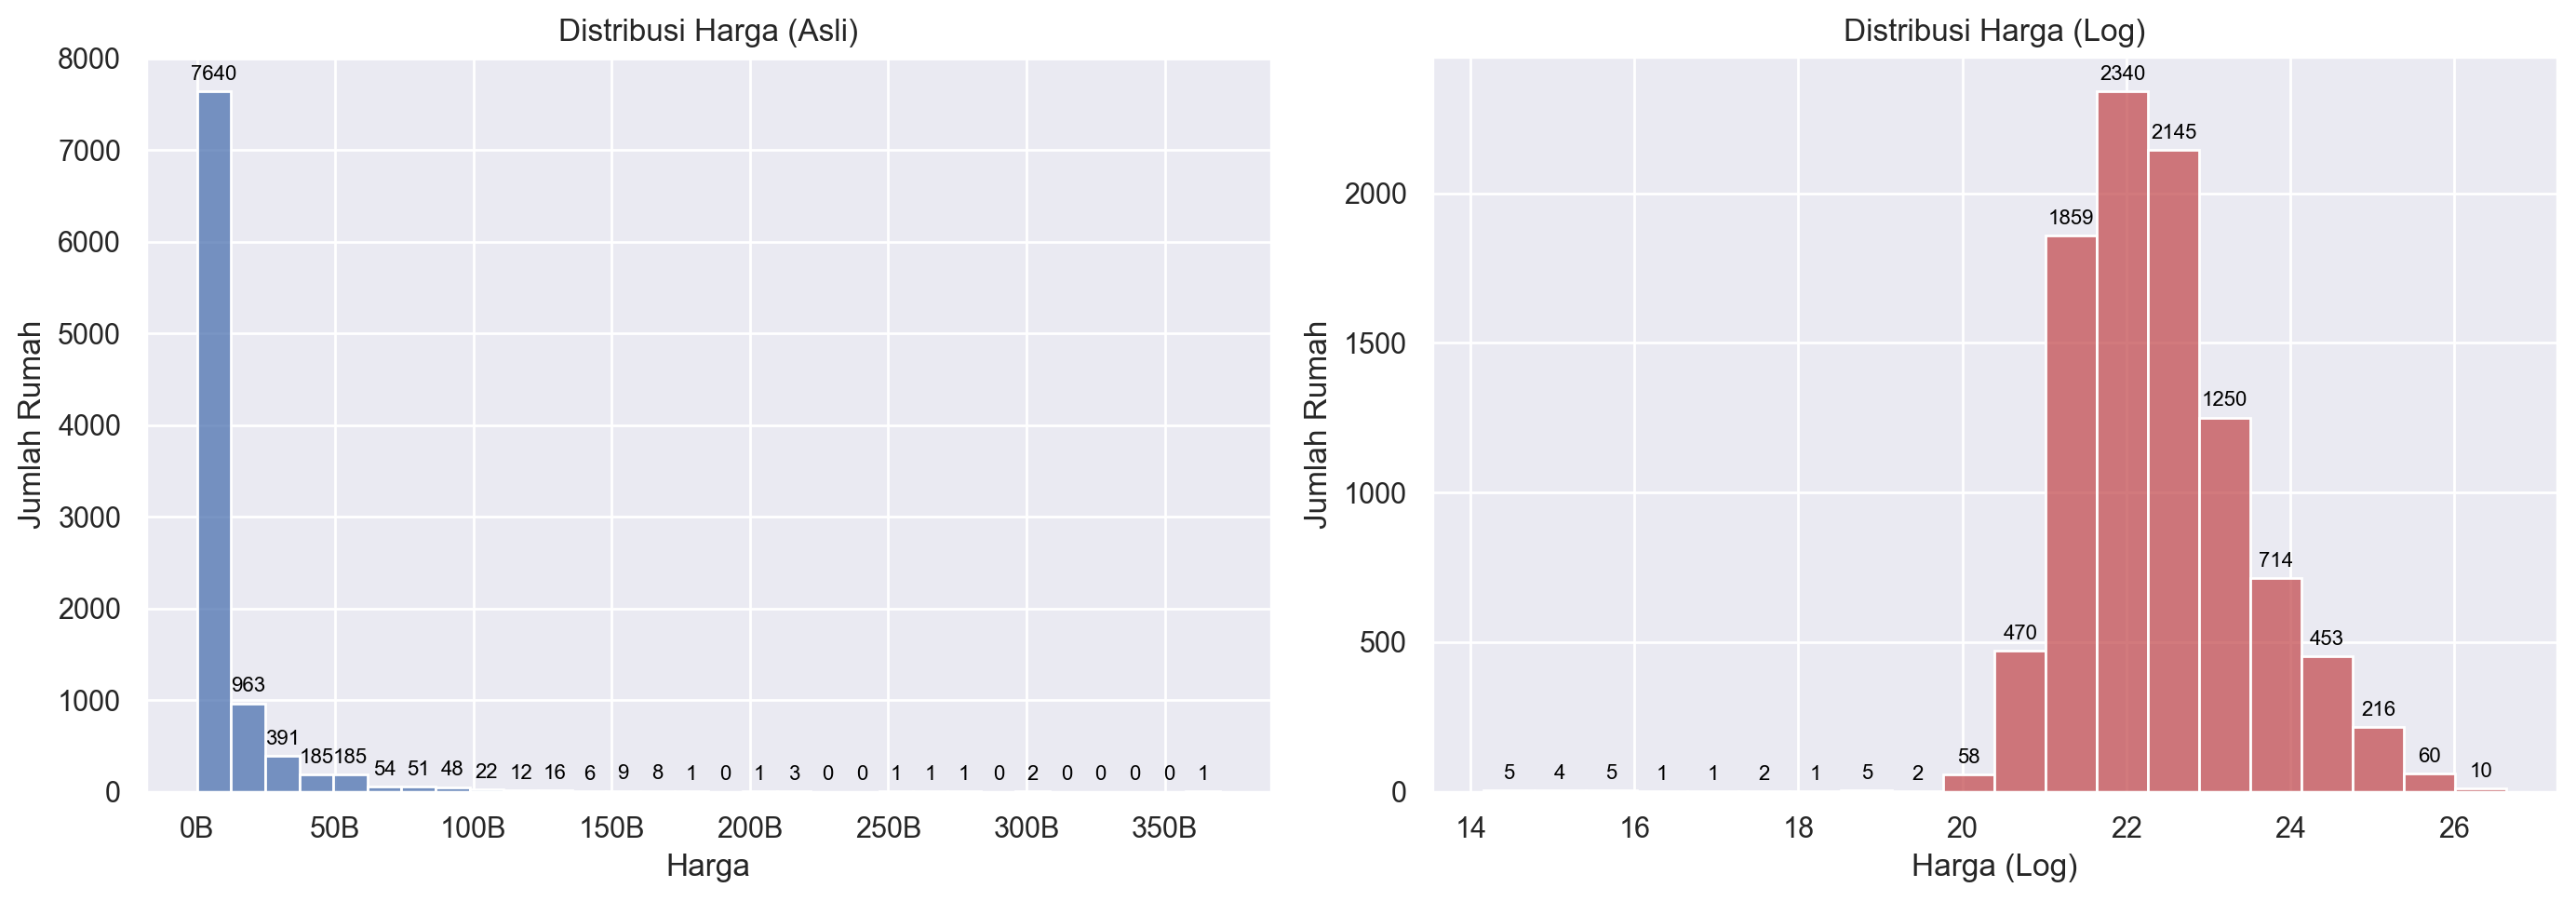

In [15]:
# Membuat figure dengan 1 baris 2 kolom dengan lebar 12 dan tinggi 5
fig , axes = plt.subplots(1,2,figsize=(14,5),dpi=200)

# Membuat axes pertama untuk menampilkan distribusi dengan nilai asli
sns.histplot(df['price_idr'],bins=30,color='b',ax=axes[0])
axes[0].bar_label(axes[0].containers[0],fontsize=8,color='black',padding=3)
axes[0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{x/1e9:.0f}B'))
axes[0].set_title('Distribusi Harga (Asli)')
axes[0].set_xlabel('Harga')
axes[0].set_ylabel('Jumlah Rumah')

# Membuat axes kedua untuk menampilkan distribusi dengan nilai log
sns.histplot(np.log1p(df['price_idr']),bins=20,color='r',ax=axes[1])
axes[1].bar_label(axes[1].containers[0],fontsize=8,color='black',padding=3)
axes[1].set_title('Distribusi Harga (Log)')
axes[1].set_xlabel('Harga (Log)')
axes[1].set_ylabel('Jumlah Rumah')

# Memberi jarak terhadap axes
fig.tight_layout()
plt.show()

### Mencari outliers menggunakan IQR (interquartile range) karena data harga asli right-skew atau tidak terdistribusi dengan normal untuk keperluan EDA

In [16]:
Q1 = df['price_idr'].quantile(0.25)
Q3 = df['price_idr'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['price_idr'] < lower) | (df['price_idr'] > upper)]
outliers_high = df[df['price_idr'] > upper]
outliers_low = df[df['price_idr'] < lower]
print(f'Batas Bawah: {lower}')
print(f'Batas Atas: {upper}')
print(f'Jumlah Total Outlier: {len(outliers)}')
print(f'Jumlah Outlier Di Bawah Batas Bawah: {len(outliers_low)}') 
print(f'Jumlah Outlier Di Atas Batas Atas: {len(outliers_high)}') 

Batas Bawah: -8600000000.0
Batas Atas: 21000000000.0
Jumlah Total Outlier: 1125
Jumlah Outlier Di Bawah Batas Bawah: 0
Jumlah Outlier Di Atas Batas Atas: 1125


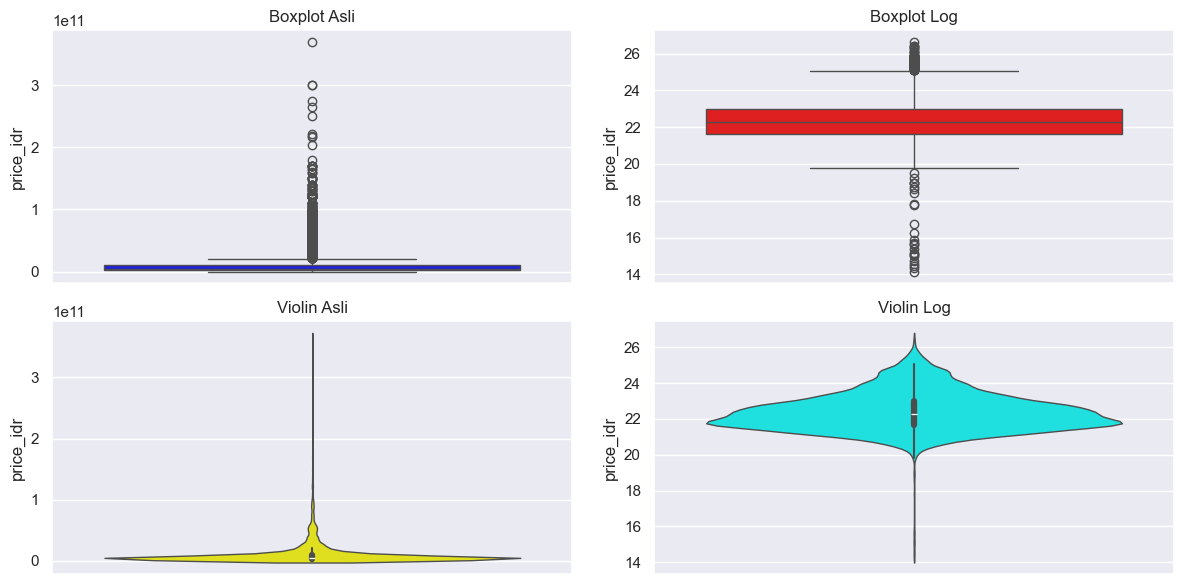

In [17]:

fig , ax = plt.subplots(2,2,figsize=(12,6))

sns.boxplot(y=df['price_idr'],ax=ax[0,0],color='blue')
ax[0,0].set_title('Boxplot Asli')

sns.boxplot(y=np.log1p(df['price_idr']),ax=ax[0,1],color='red')
ax[0,1].set_title('Boxplot Log')

sns.violinplot(y=df['price_idr'],ax=ax[1,0],bw_adjust=1, cut=1, linewidth=1,color='yellow')
ax[1,0].set_title('Violin Asli')

sns.violinplot(y=np.log1p(df['price_idr']),ax=ax[1,1],cut=1, linewidth=1,color='cyan')
ax[1,1].set_title('Violin Log')

plt.tight_layout()
plt.show()

## Insight Visualisasi Boxplot & Violin:
### Nilai Asli : Menunjukan kepadatan harga di antara 0-50M
### Nilai Log : Menunjukan sebaran harga terdistribusi dengan normal dan tidak menumpuk

## Mencari informasi data yang outliers

In [18]:
outliers.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,1.125000e+03,1125.000000,1125.000000,1125.000000,1125.000000,1125.000000
mean,5.021120e+10,7.128889,6.098667,5.295111,911.752000,841.666667
std,3.538907e+10,6.312891,6.522889,4.790079,955.103556,761.227709
min,2.150000e+10,1.000000,1.000000,0.000000,30.000000,58.000000
25%,2.700000e+10,5.000000,4.000000,2.000000,552.000000,493.000000
50%,3.900000e+10,6.000000,5.000000,4.000000,720.000000,650.000000
75%,5.800000e+10,8.000000,7.000000,7.000000,1000.000000,1000.000000
max,3.700000e+11,117.000000,117.000000,50.000000,17800.000000,12200.000000


In [19]:
na = df[(df['price_idr'] > 100_000_000_000) & ((df['land_size_m2'] < 100) | (df['building_size_m2'] < 100))]
na

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at
8102,Rumah Modern Kualitas Mewah di Cempaka Putih P...,1.020000e+11,Jakarta Pusat,Cempaka Putih,2.0,2.0,2.0,30.0,58.0,2026-04-28T09:54:51.354770+00:00
8503,Dijual Rumah Indent Lokasi Dekat Stasiun Mangg...,1.110000e+11,Jakarta Pusat,Karang Anyar,2.0,2.0,2.0,36.0,63.0,2026-04-28T10:17:03.332246+00:00
9853,Rumah Mewah 10 Menit Stasiun Besar/ Pintu Tol ...,1.310000e+11,Jakarta Pusat,Sawah Besar,3.0,3.0,2.0,43.0,68.0,2026-04-28T11:30:15.492682+00:00
9864,Rumah Minimalis Elegan 2 Lantai di Ekonomi 5 M...,1.310000e+11,Jakarta Pusat,Sawah Besar,3.0,3.0,2.0,43.0,68.0,2026-04-28T11:30:47.396109+00:00
9882,"Hanya 10 Menit ke Sudirman, Rumah Strategis di...",1.470000e+11,Jakarta Pusat,Cempaka Putih,3.0,2.0,2.0,40.0,72.0,2026-04-28T11:31:45.084899+00:00


In [20]:
df = df.drop(index=na.index)

In [21]:
df.info()

<class 'pandas.DataFrame'>
Index: 9596 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             9596 non-null   str    
 1   price_idr         9596 non-null   float64
 2   city              9596 non-null   str    
 3   district          9596 non-null   str    
 4   bedrooms          9596 non-null   float64
 5   bathrooms         9596 non-null   float64
 6   garage            9596 non-null   float64
 7   land_size_m2      9596 non-null   float64
 8   building_size_m2  9596 non-null   float64
 9   scraped_at        9596 non-null   str    
dtypes: float64(6), str(4)
memory usage: 824.7 KB


In [22]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2
count,9.596000e+03,9596.000000,9596.000000,9596.000000,9596.000000,9596.000000
mean,1.070034e+10,4.991663,4.136828,2.417049,294.030221,330.430805
std,1.906406e+10,3.756992,3.632999,2.563279,432.465188,370.144701
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000
25%,2.500000e+09,3.000000,3.000000,1.000000,105.000000,146.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,180.000000,240.000000
75%,9.900000e+09,6.000000,5.000000,3.000000,330.000000,400.000000
max,3.700000e+11,117.000000,117.000000,50.000000,17800.000000,12200.000000


In [23]:
df['title'] = df['title'].str.lower()
df['cluster'] = df['title'].str.contains('cluster', na=False).astype(int)
df['pool'] = df['title'].str.contains(r'kolam renang|pool', na=False).astype(int)
df['mrt'] = df['title'].str.contains(r'mrt', na=False).astype(int)
df['tol'] = df['title'].str.contains(r'tol', na=False).astype(int)
df['furnished'] = df['title'].str.contains(r'furnished', na=False).astype(int)
df['mall'] = df['title'].str.contains(r'mall', na=False).astype(int)
df['kos'] = df['title'].str.contains(r'kos|kost|kostan|kosan', na=False).astype(int)
df['rumah_sakit'] = (df['title'].str.contains(r'rumah sakit', na=False) &~ df['title'].str.contains(r'dekat|near|sekitar|selangkah', na=False)).astype(int)

In [24]:
df[(df['kos'] == 1) | (df['rumah_sakit'] == 1)]

,title,price_idr,city,district,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,scraped_at,cluster,pool,mrt,tol,furnished,mall,kos,rumah_sakit
3,rumah 2 lantai di tanjung duren utara cocok un...,8.500000e+09,Jakarta Barat,Tanjung Duren Utara,3.0,5.0,9.0,350.0,500.0,2026-04-28T01:42:25.528413+00:00,0,0,0,0,0,0,1,0
164,rumah kost dijual jl madrasah dekat akses mrt ...,8.000000e+09,Jakarta Selatan,Cilandak,15.0,15.0,2.0,344.0,580.0,2026-04-28T01:57:43.387920+00:00,0,0,1,0,0,0,1,0
168,dijual rumah beserta rumah kos dijati padang j...,6.500000e+09,Jakarta Selatan,Jati Padang,14.0,13.0,6.0,600.0,250.0,2026-04-28T01:57:57.992139+00:00,0,0,0,0,0,0,1,0
232,rumah tua masih layak huni terletak di segitig...,3.100000e+10,Jakarta Selatan,Karet,4.0,3.0,4.0,750.0,450.0,2026-04-28T02:01:18.776690+00:00,0,0,0,0,0,0,1,0
254,"rumah kost tebet 10 kamar tidur, fully renovat...",3.900000e+09,Jakarta Selatan,Tebet,9.0,5.0,1.0,126.0,250.0,2026-04-28T02:02:29.491060+00:00,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9949,rumah kost 24 kamar rring 1 di petojo hrg mmen...,1.300000e+10,Jakarta Pusat,Petojo,26.0,25.0,15.0,772.0,500.0,2026-04-28T11:35:17.854556+00:00,0,0,0,0,0,0,1,0
9962,rumah dijual cepat posisi hook cocok untuk kos...,3.500000e+09,Jakarta Pusat,Kemayoran,6.0,3.0,1.0,160.0,240.0,2026-04-28T11:35:59.478306+00:00,0,0,0,0,0,0,1,0
9965,"rumah huni + kos²an di cempaka putih, jakarta ...",8.800000e+09,Jakarta Pusat,Cempaka Putih,7.0,5.0,0.0,360.0,600.0,2026-04-28T11:36:08.447277+00:00,0,0,0,0,0,0,1,0
9973,jual cepat rumah jl kran kemayoran cocok untuk...,3.500000e+09,Jakarta Pusat,Kemayoran,4.0,3.0,2.0,165.0,240.0,2026-04-28T11:36:34.170433+00:00,0,0,0,0,0,0,1,0


In [25]:
df = df[(df['rumah_sakit'] == 0) & (df['kos'] == 0)]
df = df.drop(columns=['rumah_sakit','kos'])
df.info()

<class 'pandas.DataFrame'>
Index: 9265 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             9265 non-null   str    
 1   price_idr         9265 non-null   float64
 2   city              9265 non-null   str    
 3   district          9265 non-null   str    
 4   bedrooms          9265 non-null   float64
 5   bathrooms         9265 non-null   float64
 6   garage            9265 non-null   float64
 7   land_size_m2      9265 non-null   float64
 8   building_size_m2  9265 non-null   float64
 9   scraped_at        9265 non-null   str    
 10  cluster           9265 non-null   int64  
 11  pool              9265 non-null   int64  
 12  mrt               9265 non-null   int64  
 13  tol               9265 non-null   int64  
 14  furnished         9265 non-null   int64  
 15  mall              9265 non-null   int64  
dtypes: float64(6), int64(6), str(4)
memory usage: 1.2 MB


## Melihat Korelasi antar kolom
### Deskripsi:
### 0,00 – 0,25: Korelasi sangat lemah
### 0,25 – 0,50: Korelasi cukup/sedang
### 0,50 – 0,75: Korelasi kuat
### 0,75 – 0,99: Korelasi sangat kuat
### 1,00: Korelasi sempurna
### Note : Korelasi hanya menilai hubungungan antar 2 kolom bukan seluruh kolom, jadi jika korelasi lemah bukan berarti fitur tidak berguna

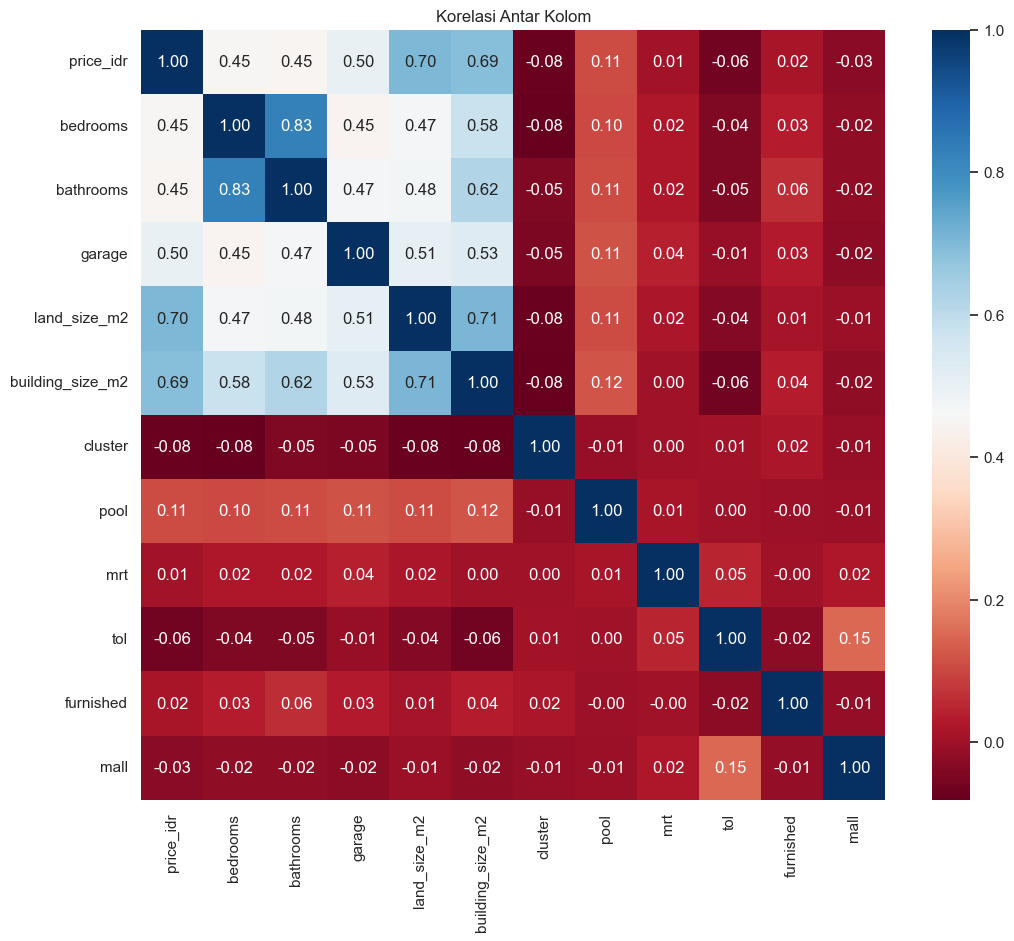

In [26]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='RdBu', fmt='.2f')
plt.title('Korelasi Antar Kolom')
plt.show()

In [27]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall
count,9.265000e+03,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000
mean,1.079908e+10,4.709876,3.919050,2.414139,294.800216,328.882785,0.060119,0.024393,0.009606,0.033028,0.045332,0.020615
std,1.928655e+10,2.349810,2.312561,2.508361,435.829029,366.580192,0.237720,0.154274,0.097544,0.178718,0.208042,0.142100
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.500000e+09,3.000000,3.000000,1.000000,105.000000,145.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,4.700000e+09,4.000000,4.000000,2.000000,180.000000,238.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.950000e+09,5.000000,5.000000,3.000000,330.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3.700000e+11,99.000000,99.000000,50.000000,17800.000000,12200.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Melihat distribusi atau sebaran kolom lain menggunakan histoplot

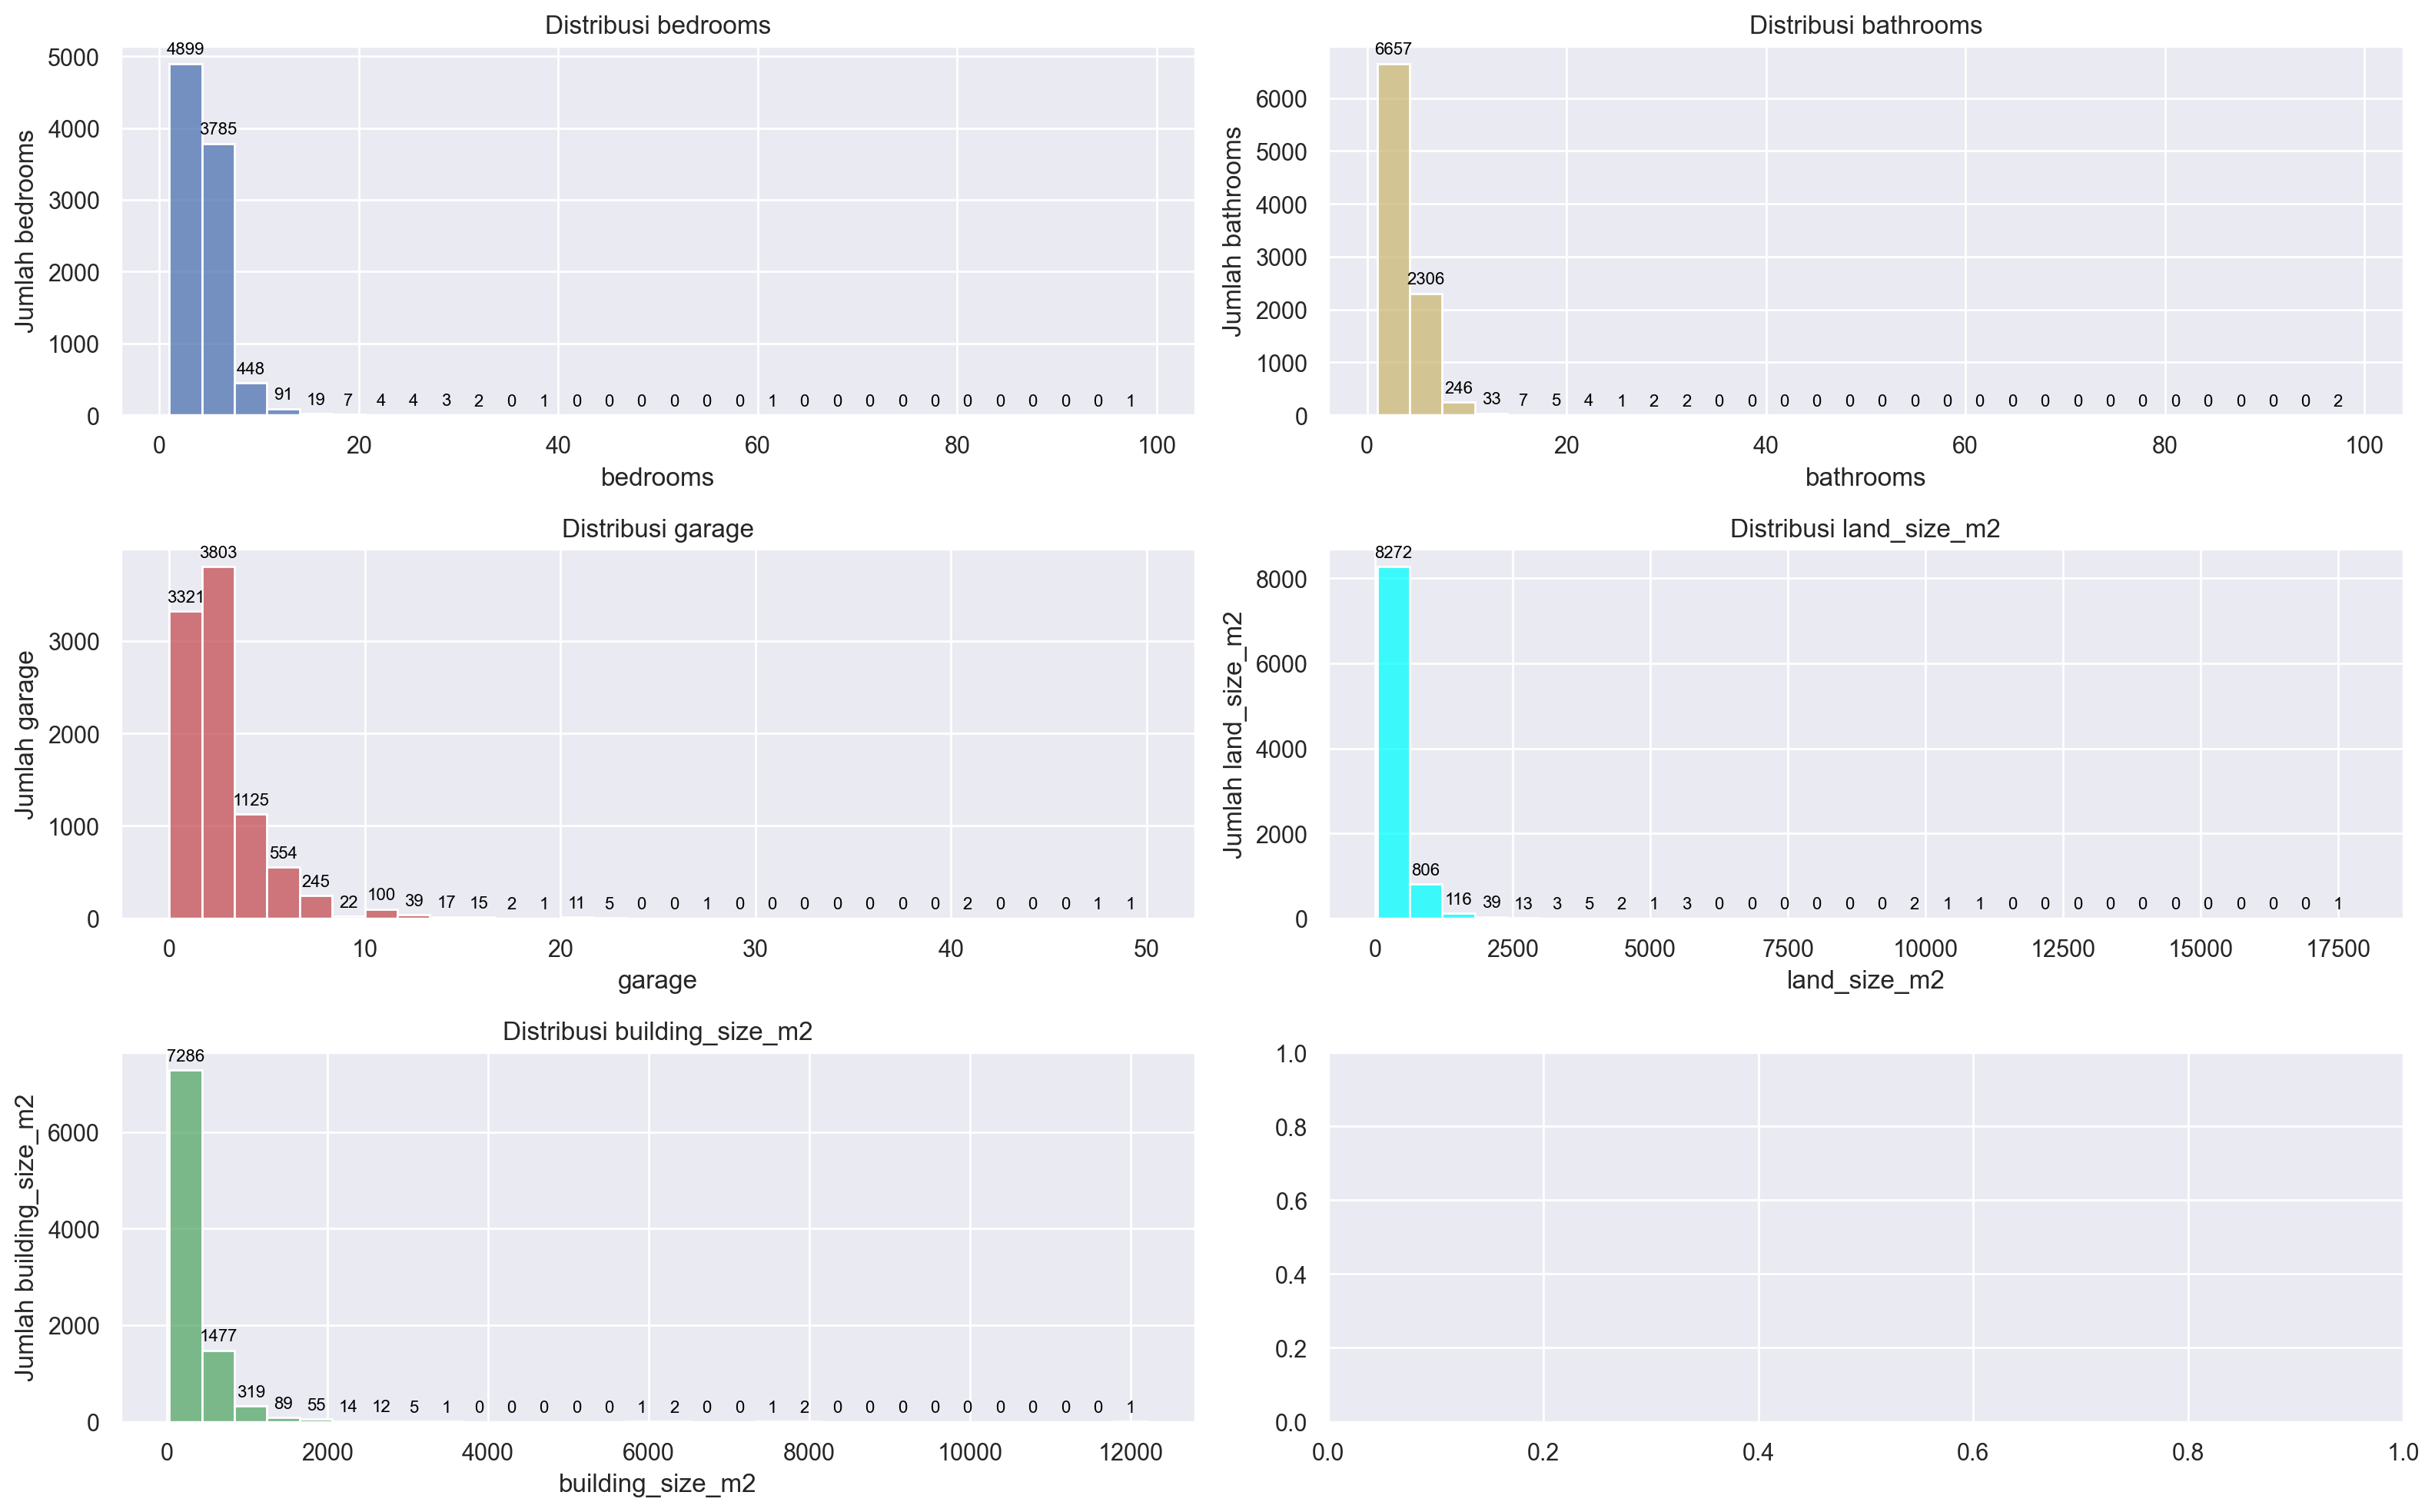

In [28]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_m2','building_size_m2']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()


In [29]:
df[df['garage'] > 10][['bedrooms', 'bathrooms', 'garage', 'land_size_m2', 'price_idr']]

,bedrooms,bathrooms,garage,land_size_m2,price_idr
31,9.0,6.0,22.0,2360.0,4.800000e+10
56,2.0,2.0,21.0,5555.0,5.500000e+10
88,18.0,20.0,12.0,584.0,4.000000e+10
89,3.0,4.0,14.0,1344.0,2.800000e+10
91,8.0,8.0,15.0,2382.0,8.900000e+10
...,...,...,...,...,...
9857,8.0,10.0,16.0,824.0,9.000000e+10
9886,8.0,8.0,12.0,420.0,8.500000e+09
9901,7.0,8.0,16.0,824.0,9.000000e+10
9905,5.0,7.0,16.0,824.0,9.000000e+10


## Memfilter atau memberi batas dan juga transformisasi pada kolom yang dibutuhkan untuk membuat distribusi menjadi normal

In [30]:
df['bedrooms']  = df['bedrooms'].clip(upper=20)
df['bathrooms'] = df['bathrooms'].clip(upper=20)
df['garage']    = df['garage'].clip(upper=20)

df['land_size_log']     = np.log1p(df['land_size_m2'])
df['building_size_log'] = np.log1p(df['building_size_m2'])

## Disribusi atau sebaran setiap kolom setelah melakukan normalisasi dengan cara clip dan log


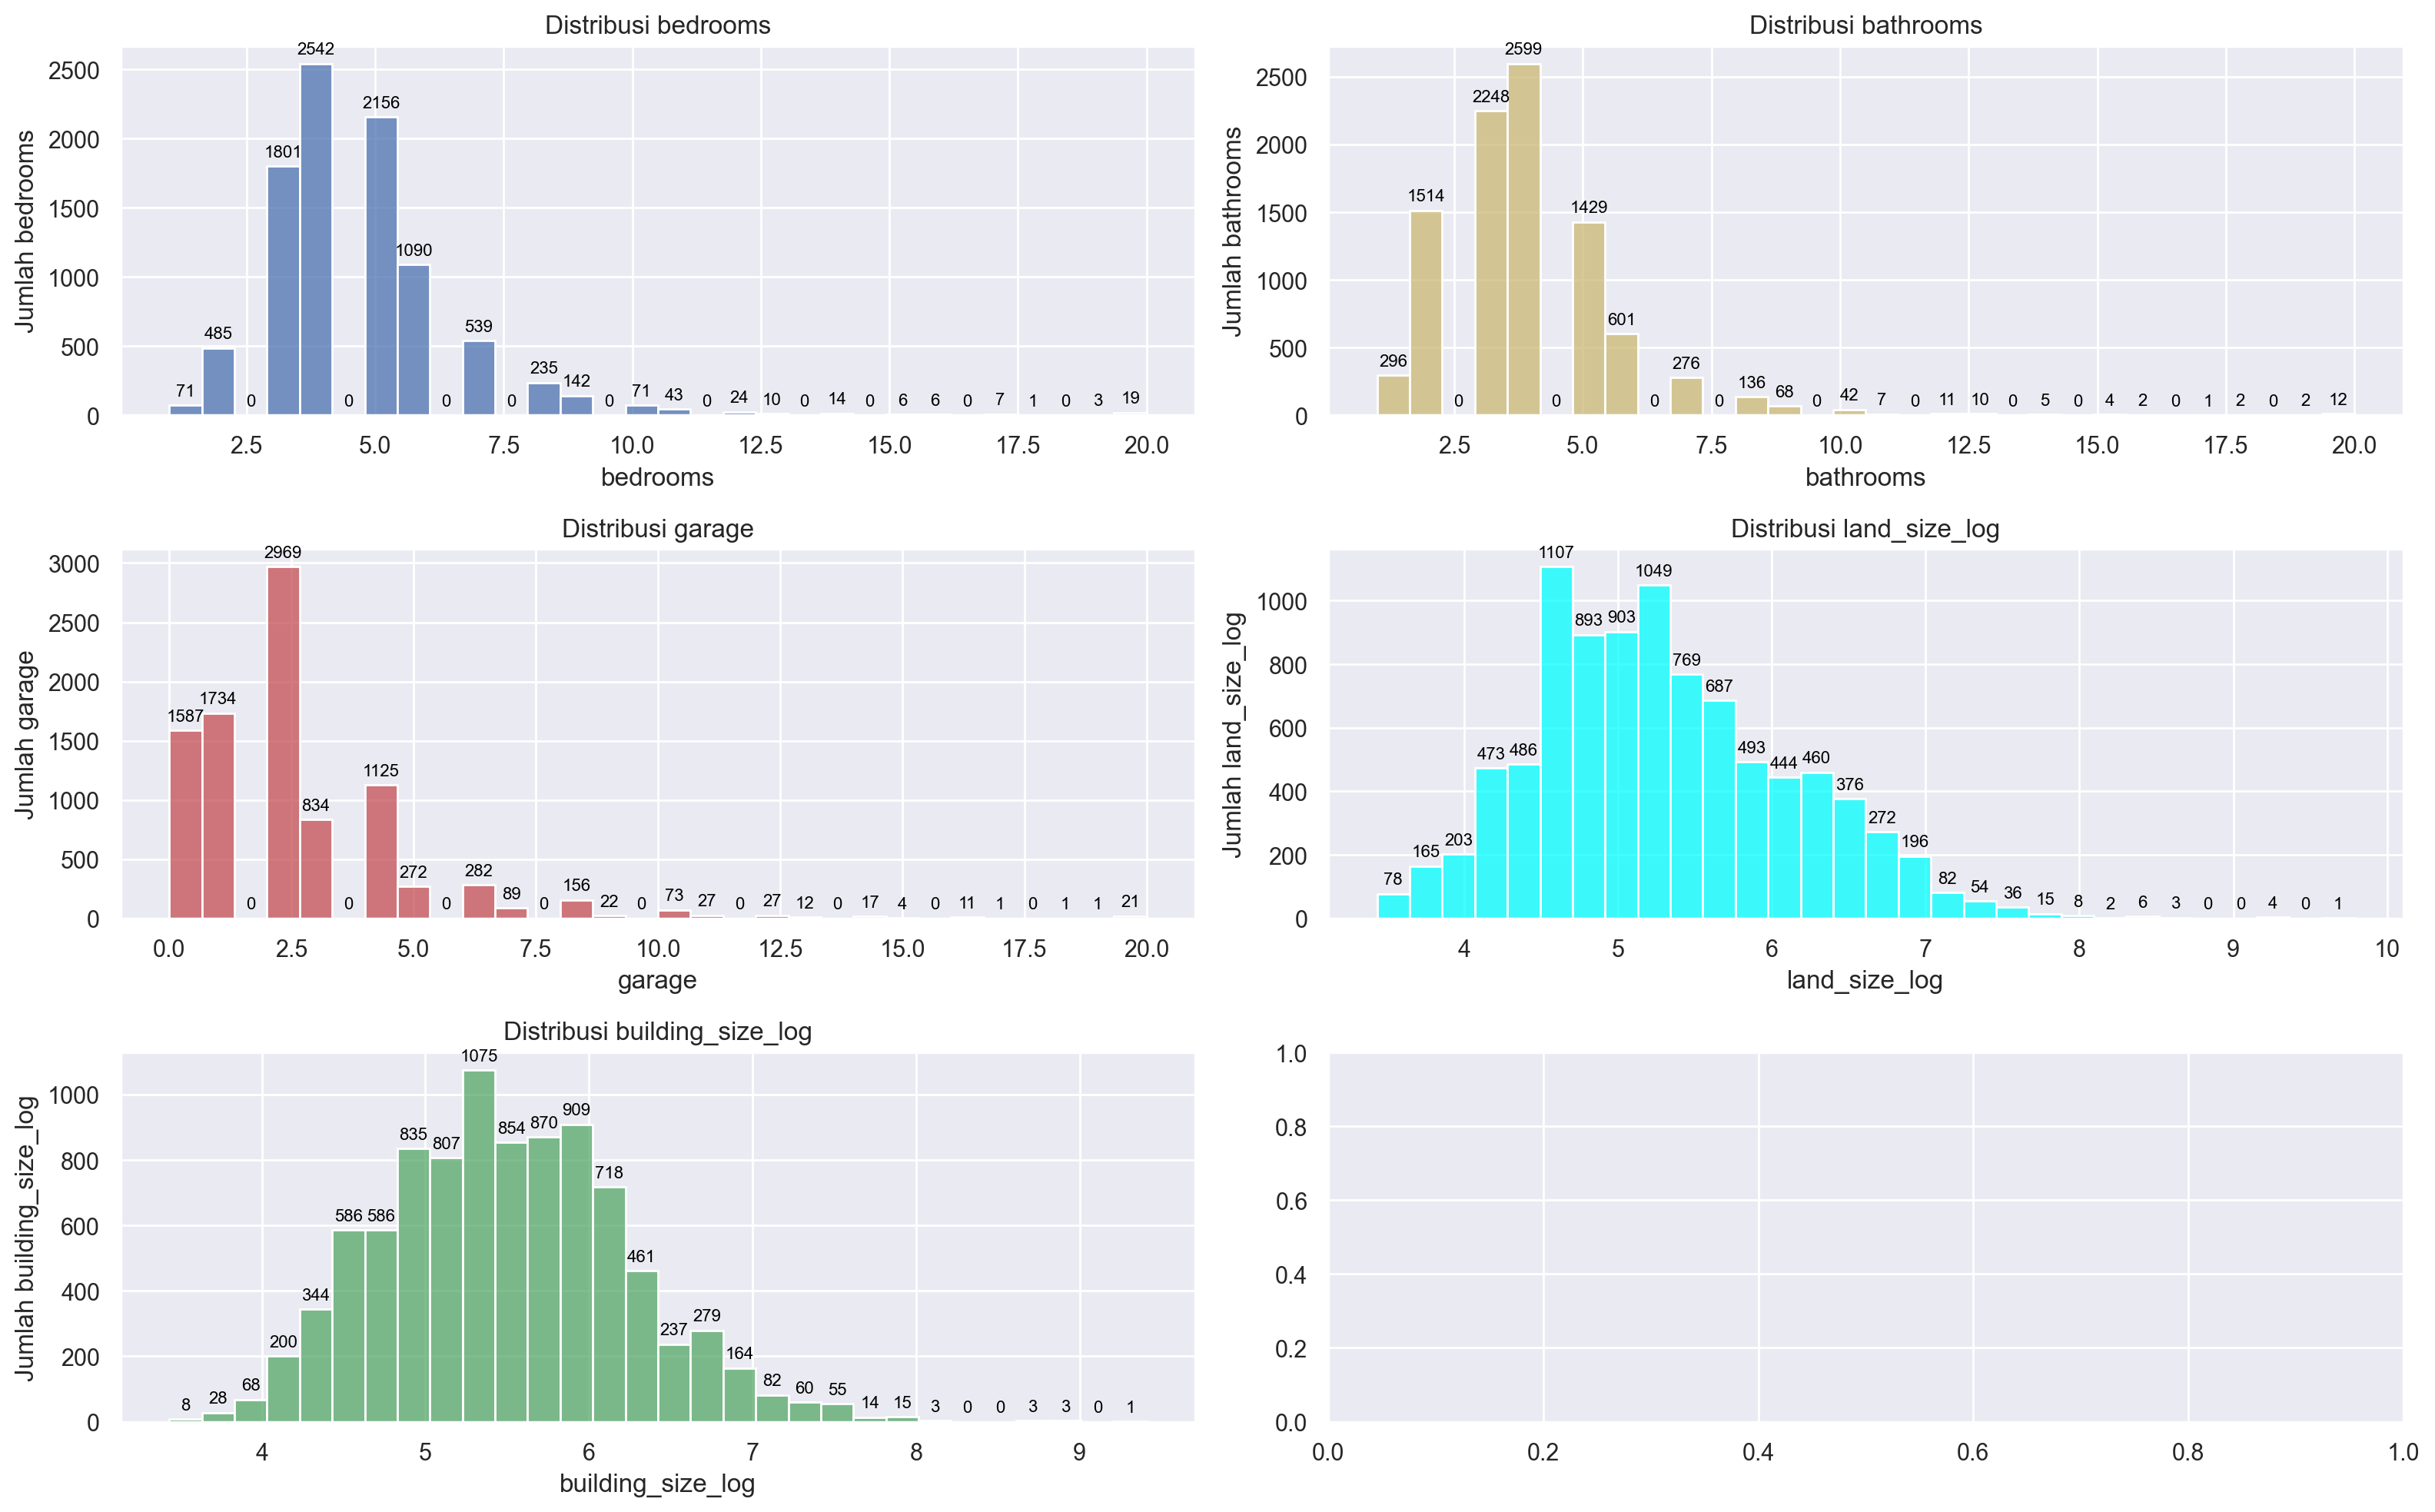

In [31]:
fig , axes = plt.subplots(3,2,figsize=(16,10),dpi=200)
axes = axes.flatten()

columns = ['bedrooms','bathrooms','garage','land_size_log','building_size_log']
collor = ['b','y','r','cyan','g']
col = zip(columns,collor)
n = 0

for k,v in col:
    sns.histplot(df[k],bins=30,color=v,ax=axes[n])
    axes[n].bar_label(axes[n].containers[0],fontsize=8,color='black',padding=3)
    axes[n].set_ylabel(f'Jumlah {k}')
    axes[n].set_title(f'Distribusi {k}')
    n = n+1

fig.tight_layout()
plt.show()

In [32]:
df.describe()

,price_idr,bedrooms,bathrooms,garage,land_size_m2,building_size_m2,cluster,pool,mrt,tol,furnished,mall,land_size_log,building_size_log
count,9.265000e+03,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000,9265.000000
mean,1.079908e+10,4.686454,3.896276,2.401511,294.800216,328.882785,0.060119,0.024393,0.009606,0.033028,0.045332,0.020615,5.285809,5.496161
std,1.928655e+10,1.960539,1.793089,2.361591,435.829029,366.580192,0.237720,0.154274,0.097544,0.178718,0.208042,0.142100,0.839155,0.742091
min,1.400000e+06,1.000000,1.000000,0.000000,30.000000,30.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.433987,3.433987
25%,2.500000e+09,3.000000,3.000000,1.000000,105.000000,145.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.663439,4.983607
50%,4.700000e+09,4.000000,4.000000,2.000000,180.000000,238.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.198497,5.476464
75%,9.950000e+09,5.000000,5.000000,3.000000,330.000000,400.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.802118,5.993961
max,3.700000e+11,20.000000,20.000000,20.000000,17800.000000,12200.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,9.787010,9.409273


In [33]:
low, high = df['price_idr'].quantile([0.01, 0.99])
print(low, high)

df['price_idr'] = df['price_idr'].clip(low, high)

750000000.0 95000000000.0


In [34]:
df = pd.get_dummies(df, columns=['city'], dtype=int)

## Menghapus kolom yang tidak butuhkan untuk tahap training model


In [35]:
df = df.drop(columns=['scraped_at','title'])

# Save data yang bersih ke CSV

In [ ]:
df.to_csv('../data/raw/jakarta_properties_clear.csv',index=False)

district
Kelapa Gading         550
Cempaka Putih         445
Menteng               415
Pantai Indah Kapuk    363
Sunter                341
                     ... 
Kampung Ambon           1
Hasyim Ashari           1
Harmoni                 1
Samanhudi               1
Hayam Wuruk             1
Name: count, Length: 246, dtype: int64